# 01 — Data Exploration

This notebook looks at the seven data files and explains what is in them. It also rebuilds the order
funnel: how 1,109 open orders become the smaller group that needs a decision.

It runs on its own. It reads nothing from other notebooks and it saves nothing.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

This notebook runs on its own. It reads the data files, does its own work, and prints the results.
It does not upload anything, and it does not save any files.

Set `DATA_DIR` below to the folder that holds the CSV files. If the folder is somewhere under the
current directory, the notebook finds it by itself.

In [ ]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Put the path to your data folder here, or leave it as None to search for it.
DATA_DIR = "/content/drive/MyDrive/DOM-data"

def find_data(start=DATA_DIR):
    """Return the folder that holds input_order data.csv."""
    if start and os.path.isfile(os.path.join(start, "input_order data.csv")):
        return start
    for hit in glob.glob("**/input_order data.csv", recursive=True):
        return os.path.dirname(hit)          # first match wins
    raise FileNotFoundError(
        "Could not find 'input_order data.csv'. Set DATA_DIR to the folder that holds the CSV files.")

IN = find_data()                              # folder with the 5 input files
ROOT = os.path.dirname(IN) if os.path.basename(IN) == "input data" else IN
print("input folder :", IN)

input folder : drive/MyDrive/DOM/dom_extract/Nestle - WISER WQ26 DOM-data [SHARED]/DOM-data/input data


## 2. Read the data

Five input files. Two output files come from the earlier model run; we use them only to check our
own numbers, never as input.

In [ ]:
orders = pd.read_csv(f"{IN}/input_order data.csv")            # one row per order and SKU
cap    = pd.read_csv(f"{IN}/input_capacity_planning.csv")     # daily stock per DC and SKU
dock   = pd.read_csv(f"{IN}/input_dock_capacity.csv")         # daily dock slots per DC
ship   = pd.read_csv(f"{IN}/input_shipping_cost_data.csv")    # cost per DC to zip lane
thru   = pd.read_csv(f"{IN}/input_throughput_capacity.csv")   # daily pick work per DC

def read_output(name):
    """The two output files may sit beside the input folder or one level up."""
    for p in [f"{ROOT}/{name}", f"{IN}/{name}", f"{ROOT}/../{name}"]:
        if os.path.isfile(p):
            return pd.read_csv(p)
    return None

poc_ord = read_output("Output_order_level_data.csv")          # check only
poc_sku = read_output("output_order_sku_level_data.csv")      # check only

for n, d in [("orders", orders), ("capacity", cap), ("dock", dock),
             ("shipping", ship), ("throughput", thru)]:
    print(f"{n:11s} {d.shape}")

orders      (25193, 39)
capacity    (377504, 23)
dock        (480, 13)
shipping    (12922, 7)
throughput  (530, 7)


## 3. The order book

`input_order data.csv` has one row per order line. `Group_Flag` is the order number. The file is
already filtered: every row is a full truckload and every delivery note is still open. So two
business rules are already applied. We check that instead of assuming it.

In [ ]:
print("rows:", len(orders), "| orders:", orders.Group_Flag.nunique(),
      "| SKUs:", orders.MaterialNumber.nunique(), "| DCs:", orders.Plant.nunique())

ftl = orders["IsFTL"].str.strip().str.upper().value_counts()
dnf = orders["DeliveryNoteFlag"].str.strip().str.upper().value_counts()
print("IsFTL:", ftl.to_dict(), "| DeliveryNoteFlag:", dnf.to_dict())

print("plants:", sorted(orders.Plant.unique()))
print("priority orders:", orders.groupby("DeliveryPriority").Group_Flag.nunique().to_dict())

rows: 25193 | orders: 1109 | SKUs: 1110 | DCs: 8
IsFTL: {'Y': 25193} | DeliveryNoteFlag: {'N': 25193}
plants: [np.int64(5083), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5490), np.int64(5620), np.int64(5641), np.int64(5773)]
priority orders: {8: 12, 99: 1097}


### 3.1 The columns the model uses

The order file has 39 columns. The model needs about a dozen.

In [ ]:
use = pd.DataFrame([
    ("Group_Flag",                 "order number"),
    ("Plant",                      "the DC the order uses today"),
    ("MaterialNumber",             "SKU, joins to the stock file"),
    ("transportationplanningdate", "planned ship day"),
    ("RequestedDeliveryDate",      "customer due day"),
    ("IsInvAvail",                 "Y/N per line: covered by stock at its own DC"),
    ("DeliveryPriority",           "8 = protected order, 99 = normal"),
    ("OrderedQty_converted",       "quantity, in the unit named by the UoM column"),
    ("ProductCasesPerPallet",      "cases per pallet"),
    ("Order_SKU_Revenue",          "money on the line"),
    ("ZipCode",                    "ship-to zip, joins to the freight file"),
    ("FillRateThreshold",          "fill % below which a penalty starts"),
    ("Penaltyforpotentialcuts",    "penalty rate on the missing value"),
], columns=["column", "what it is for"])
print(use.to_string(index=False))

                    column                                what it is for
                Group_Flag                                  order number
                     Plant                   the DC the order uses today
            MaterialNumber                  SKU, joins to the stock file
transportationplanningdate                              planned ship day
     RequestedDeliveryDate                              customer due day
                IsInvAvail  Y/N per line: covered by stock at its own DC
          DeliveryPriority              8 = protected order, 99 = normal
      OrderedQty_converted quantity, in the unit named by the UoM column
     ProductCasesPerPallet                              cases per pallet
         Order_SKU_Revenue                             money on the line
                   ZipCode        ship-to zip, joins to the freight file
         FillRateThreshold           fill % below which a penalty starts
   Penaltyforpotentialcuts             penalty rate

## 4. Stock, docks, freight and picking

Two of these files have gaps that shape the model, so it is worth seeing them now.

- **Stock** — a daily line per DC and SKU. We need one number: how many cases are free to use.
- **Docks** — free slots per DC per day. Two DCs have no rows at all.
- **Throughput** — usage only, never a limit. There is no capacity ceiling anywhere in the pack.
- **Freight** — a full rate card, so every DC can quote every ship-to zip.

In [ ]:
cap["DATE"] = pd.to_datetime(cap["DATE"])
cap["AV"] = cap["OpeningStock"] - cap["Total_Reserved_Qty"]      # free cases
DCS = sorted(orders["Plant"].unique())
print("stock rows:", len(cap), "| DC-SKU pairs:",
      cap.groupby(["LocationID", "MaterialID"]).ngroups)
print("days:", cap.DATE.min().date(), "->", cap.DATE.max().date())
print("free stock is >= 0 on", f"{(cap.AV >= 0).mean()*100:.1f}%", "of rows")

dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y")
print("\ndock rows:", len(dock), "| DCs with dock data:", sorted(dock.Plant.unique()))
print("DCs with NO dock data:", [d for d in DCS if d not in set(dock.Plant)])
print("fully booked DC-days:", int((dock.Dock_Remaining == 0).sum()))

print("\nthroughput columns:", list(thru.columns))
print("-> usage only, no stated maximum")

lanes = set(zip(ship.Plant, ship.TargetZip))
need  = set((d, z) for d in DCS for z in orders.ZipCode.unique())
print("\nfreight rows:", len(ship), "| missing DC-to-zip lanes:", len(need - lanes))

stock rows: 377504 | DC-SKU pairs: 11797
days: 2024-06-20 -> 2024-07-21
free stock is >= 0 on 100.0% of rows

dock rows: 480 | DCs with dock data: [np.int64(5159), np.int64(5385), np.int64(5410), np.int64(5420), np.int64(5423), np.int64(5490), np.int64(5620), np.int64(5641)]
DCs with NO dock data: [np.int64(5083), np.int64(5773)]
fully booked DC-days: 43

throughput columns: ['Plant', 'transportationplanningdate', 'util_case_picks', 'util_pallets', 'order_count', 'Day', 'Report_Run_Date']
-> usage only, no stated maximum

freight rows: 12922 | missing DC-to-zip lanes: 0


### 4.1 Transit time is not given, but we can work it out

Nothing in the files says how long a delivery takes. The earlier model output does, and it is simply
`distance / 500`, rounded up. We check that before using it.

In [ ]:
if poc_ord is not None:
    v = poc_ord[["DefaultDCDistance", "DefaultDCLeadTime"]].dropna().drop_duplicates()
    ok = (np.maximum(1, np.ceil(v.DefaultDCDistance / 500)) == v.DefaultDCLeadTime).mean()
    print("transit days == distance / 500, rounded up:", round(ok, 6))
else:
    print("output file not found, skipping this check")

transit days == distance / 500, rounded up: 1.0


## 5. Pallets become cases

The rules work in cases. Some lines are measured in pallets, so we convert them. If this is right,
our case count matches the earlier model's own count exactly.

In [ ]:
print(orders.ProductPlanningUnitOfMeasure.value_counts().to_dict())

cases = np.where(orders["ProductPlanningUnitOfMeasure"].eq("PL"),
                 orders["OrderedQty_converted"] * orders["ProductCasesPerPallet"],
                 orders["OrderedQty_converted"]).astype(float)

if poc_sku is not None:
    chk = orders.assign(cases=cases).merge(
        poc_sku[["SalesDocument/GroupingIndicator", "MaterialNumber", "OrderedQty_Cases"]],
        left_on=["Group_Flag", "MaterialNumber"],
        right_on=["SalesDocument/GroupingIndicator", "MaterialNumber"], how="left")
    print("our cases match the earlier output:",
          round((chk["cases"] == chk["OrderedQty_Cases"]).mean(), 6))

{'CS': 24820, 'PL': 373}
our cases match the earlier output: 1.0


## 6. The order funnel

An order needs a decision for one of two reasons.

1. **Short of stock.** Any line of the order has `IsInvAvail = N`.
2. **No room to ship.** The rules add orders when a DC runs out of throughput for three days in a
   row. The files have no throughput limit, so a fully booked dock day stands in for it.

In [ ]:
head_dc  = orders.groupby("Group_Flag")["Plant"].first()
head_pgi = pd.to_datetime(orders.groupby("Group_Flag")["transportationplanningdate"].first(),
                          format="%m/%d/%y")

roll   = orders.groupby("Group_Flag")["IsInvAvail"].apply(
             lambda s: (s.str.upper() == "Y").all())
SUFF, INSUFF = set(roll[roll].index), set(roll[~roll].index)

zero_days = set(map(tuple, dock.loc[dock["Dock_Remaining"] == 0, ["Plant", "Date"]]
                              .drop_duplicates().values))
ADDED = {g for g in head_dc.index if (head_dc[g], head_pgi[g]) in zero_days} & SUFF

FOCUS  = sorted(INSUFF | ADDED)
CLEANO = sorted(set(head_dc.index) - set(FOCUS))

print(f"open orders          : {len(head_dc)}")
print(f"  short of stock     : {len(INSUFF)}")
print(f"  + no dock that day : {len(ADDED)}")
print(f"  = focus orders     : {len(FOCUS)}")
print(f"  fine, stay put     : {len(CLEANO)}")

open orders          : 1109
  short of stock     : 447
  + no dock that day : 25
  = focus orders     : 472
  fine, stay put     : 637


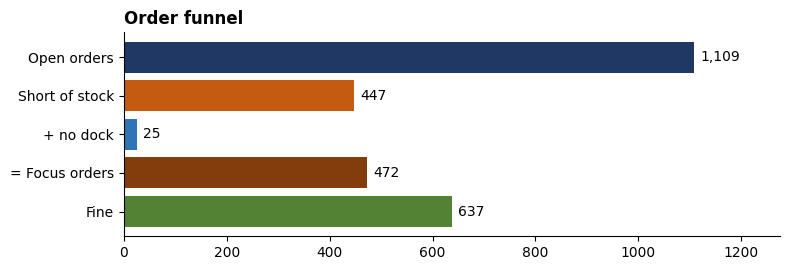

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = [("Open orders", len(head_dc), "#1f3864"), ("Short of stock", len(INSUFF), "#c55a11"),
        ("+ no dock", len(ADDED), "#2e75b6"), ("= Focus orders", len(FOCUS), "#833c0c"),
        ("Fine", len(CLEANO), "#548235")]
ax.barh([b[0] for b in bars][::-1], [b[1] for b in bars][::-1],
        color=[b[2] for b in bars][::-1])
for i, b in enumerate(bars[::-1]):
    ax.text(b[1] + 12, i, f"{b[1]:,}", va="center")
ax.set_xlim(0, len(head_dc) * 1.15)
ax.set_title("Order funnel", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 6.1 Check against the earlier model output

That file counts short orders a different way: it compares cases filled against cases ordered. The
two views should be close but not identical, because our flag was recorded before the model ran.

In [ ]:
if poc_ord is not None:
    short_poc = (poc_ord.Default_Qty_Cases < poc_ord.OrderedQty_Cases).sum()
    print(f"ours (flag)            : {len(INSUFF)} short / {len(SUFF)} fine")
    print(f"earlier output (cases) : {short_poc} short / {len(poc_ord) - short_poc} fine")
    print(f"moves it recommended   : {int((poc_ord.IsDivert != 'Default').sum())}")

ours (flag)            : 447 short / 662 fine
earlier output (cases) : 486 short / 623 fine
moves it recommended   : 3


## 7. What we found

* The order file is already filtered to full truckloads and open orders.
* Pallet lines convert to cases exactly as the earlier model did, so the quantities are safe to use.
* **Three things are missing from the files**, and each one forces an assumption later: a throughput
  limit, a holiday calendar, and a demand forecast.
* Two DCs have no dock rows, so we cannot check docks there.
* Transit time can be worked out from distance and matches the earlier output on every row.
* The funnel gives **472 focus orders**. The other 637 are filled from their own DC.